# Trader Sentiment Analysis

## Objective
Analyze how trader behavior and performance change under Fear vs Greed market conditions, and identify patterns that drive profitability.

## Dataset Overview
- Trades data
- Sentiment data (Fear & Greed Index)

In [57]:
pip install pandas numpy matplotlib seaborn scikit-learn plotly streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 81.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 70.9 MB/s eta 0:00:00


In [33]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


plt.style.use("dark_background")

# Colors for each sentiment
colors_map = {
    "Extreme Fear": "#c0392b",
    "Fear": "#e74c3c",
    "Neutral": "#f39c12",
    "Greed": "#2ecc71",
    "Extreme Greed": "#1a8a4a"
}

print("Setup complete ")

Setup complete 


In [34]:
fg_raw  = pd.read_csv("fear_greed_index.csv")
trd_raw = pd.read_csv("historical_data.csv")

print(f"Fear/Greed  → {fg_raw.shape}  | NaN: {fg_raw.isnull().sum().sum()} | Dupes: {fg_raw.duplicated().sum()}")
print(f"Trader data → {trd_raw.shape} | NaN: {trd_raw.isnull().sum().sum()} | Dupes: {trd_raw.duplicated().sum()}")
print(f"\nFear/Greed date range : {fg_raw['date'].min()} → {fg_raw['date'].max()}")
print(f"Unique traders        : {trd_raw['Account'].nunique()}")
print(f"\nSentiment distribution:")
print(fg_raw['classification'].value_counts().to_string())
print(f"\nTop 5 coins by trade count:")
print(trd_raw['Coin'].value_counts().head().to_string())
print(f"\nDirection breakdown:")
print(trd_raw['Direction'].value_counts().to_string())


Fear/Greed  → (2644, 4)  | NaN: 0 | Dupes: 0
Trader data → (211224, 16) | NaN: 0 | Dupes: 0

Fear/Greed date range : 2018-02-01 → 2025-05-02
Unique traders        : 32

Sentiment distribution:
classification
Fear             781
Greed            633
Extreme Fear     508
Neutral          396
Extreme Greed    326

Top 5 coins by trade count:
Coin
HYPE    68005
@107    29992
BTC     26064
ETH     11158
SOL     10691

Direction breakdown:
Direction
Open Long                    49895
Close Long                   48678
Open Short                   39741
Close Short                  36013
Sell                         19902
Buy                          16716
Spot Dust Conversion           142
Short > Long                    70
Long > Short                    57
Auto-Deleveraging                8
Liquidated Isolated Short        1
Settlement                       1


In [36]:
fg = fg_raw.copy()
fg["date"]      = pd.to_datetime(fg["date"]).dt.normalize()
fg              = fg.drop_duplicates("date").sort_values("date").reset_index(drop=True)
fg["is_greed"]  = fg["classification"].isin({"Greed","Extreme Greed"}).astype(int)
fg["sentiment"] = fg["is_greed"].map({1:"Greed",0:"Fear"})


trd = trd_raw.copy()
trd["datetime"] = pd.to_datetime(trd["Timestamp IST"], format="%d-%m-%Y %H:%M", dayfirst=True)
trd["date"]     = trd["datetime"].dt.normalize()

# Feature flags
trd["is_long_side"] = trd["Side"].eq("BUY").astype(int)
trd["is_win"]       = (trd["Closed PnL"] > 0).astype(int)
trd["is_loss"]      = (trd["Closed PnL"] < 0).astype(int)
trd["is_liq"]       = trd["Direction"].str.contains("Liquidat", case=False, na=False).astype(int)
trd["net_pnl"]      = trd["Closed PnL"] - trd["Fee"]

# Leverage proxy (closing trades only, start pos > 0)
trd["lev_proxy"] = np.where(
    (trd["Start Position"].abs()>0) & (trd["Direction"].isin(["Close Long","Close Short"])),
    (trd["Size USD"]/trd["Start Position"].abs()).clip(1,100), np.nan)

# Merged rows for
trd = trd.merge(fg[["date","value","classification","is_greed","sentiment"]], on="date", how="inner")
print(f"Merged rows   : {len(trd):,}")
print(f"Date range    : {trd['date'].min().date()} → {trd['date'].max().date()}")
print(f"Fear trades   : {(trd['sentiment']=='Fear').sum():,}")
print(f"Greed trades  : {(trd['sentiment']=='Greed').sum():,}")


Merged rows   : 211,218
Date range    : 2023-05-01 → 2025-05-01
Fear trades   : 120,923
Greed trades  : 90,295


In [37]:
# Per-account daily metrics
daily = (trd.groupby(["Account","date","sentiment","is_greed","value"])
           .agg(daily_pnl=("net_pnl","sum"), trade_count=("net_pnl","count"),
                win_rate=("is_win","mean"), avg_size_usd=("Size USD","mean"),
                total_fees=("Fee","sum"), long_ratio=("is_long_side","mean"),
                liquidations=("is_liq","sum"), avg_lev=("lev_proxy","mean"))
           .reset_index())
daily = daily.sort_values(["Account","date"])
daily["cum_pnl"]  = daily.groupby("Account")["daily_pnl"].cumsum()
daily["roll_max"] = daily.groupby("Account")["cum_pnl"].cummax()
daily["drawdown"] = daily["cum_pnl"] - daily["roll_max"]   # ≤ 0


mkt = (trd.groupby(["date","sentiment","is_greed","value"])
          .agg(market_pnl=("net_pnl","sum"), total_trades=("net_pnl","count"),
               avg_win_rate=("is_win","mean"), avg_size_usd=("Size USD","mean"),
               long_ratio=("is_long_side","mean"), liquidations=("is_liq","sum"),
               total_fees=("Fee","sum"))
          .reset_index())


trader_sum = (trd.groupby("Account")
                .agg(total_pnl=("net_pnl","sum"), total_trades=("net_pnl","count"),
                     win_rate=("is_win","mean"), avg_size_usd=("Size USD","mean"),
                     long_ratio=("is_long_side","mean"), liquidations=("is_liq","sum"),
                     avg_lev=("lev_proxy","mean"), total_fees=("Fee","sum"))
                .reset_index())
trader_sum["lev_seg"]  = pd.qcut(trader_sum["avg_lev"].fillna(trader_sum["avg_lev"].median()),
                                  q=3, labels=["Low Lev","Med Lev","High Lev"])
trader_sum["freq_seg"] = pd.qcut(trader_sum["total_trades"],q=3,
                                  labels=["Infrequent","Moderate","Frequent"])
pq = trader_sum["total_pnl"].quantile([0.33,0.67])
trader_sum["perf_seg"] = pd.cut(trader_sum["total_pnl"],
    bins=[-np.inf,pq[0.33],pq[0.67],np.inf],
    labels=["Consistent Loser","Inconsistent","Consistent Winner"])

print(f"Daily rows: {len(daily):,}  |  Market-level days: {len(mkt):,}  |  Traders: {len(trader_sum)}")
print("\nTrader summary preview:")
trader_sum[["Account","total_trades","total_pnl","win_rate","avg_lev"]].sort_values("total_pnl",ascending=False).head(5)


Daily rows: 2,340  |  Market-level days: 479  |  Traders: 32

Trader summary preview:


,Account,total_trades,total_pnl,win_rate,avg_lev
27,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,14733,2.127387e+06,0.337134,24.427809
0,0x083384f897ee0f19899168e3b1bec365f52a9012,3818,1.592825e+06,0.359612,19.211177
29,0xbaaaf6571ab7d571043ff1e313a9609a10637864,21192,9.315671e+05,0.467582,1.079187
31,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,40184,8.227277e+05,0.428230,2.621992
13,0x513b8629fe877bb581bf244e326a047b249c4ff1,12236,7.639979e+05,0.401193,54.588171


In [41]:
from scipy import stats
print("Performance Comparison: Fear vs Greed Days")
print("="*55)
for sent in ["Fear","Greed"]:
    sub = daily[daily["sentiment"]==sent]
    print(f"  {sent:6s} | PnL/day=${sub['daily_pnl'].mean():+8.2f} | "
          f"Win rate={sub['win_rate'].mean():.2%} | "
          f"Drawdown=${sub['drawdown'].mean():.0f} | "
          f"Trades/day={sub['trade_count'].mean():.1f}")

t_p, p_p = stats.ttest_ind(daily[daily["sentiment"]=="Fear"]["daily_pnl"],
                             daily[daily["sentiment"]=="Greed"]["daily_pnl"])
t_w, p_w = stats.ttest_ind(daily[daily["sentiment"]=="Fear"]["win_rate"],
                             daily[daily["sentiment"]=="Greed"]["win_rate"])
print(f"\n  t-test daily PnL  → p={p_p:.4f} {' sig' if p_p<0.05 else ' NOT significant'}")
print(f"  t-test win rate   → p={p_w:.4f} {' sig' if p_w<0.05 else ' NOT significant'}")
print("\n  INSIGHT: Absolute PnL is NOT driven by sentiment label alone.")
print("   The signal is in BEHAVIOUR — how traders change sizing, frequency, direction.")


Performance Comparison: Fear vs Greed Days
  Fear   | PnL/day=$+4488.39 | Win rate=35.65% | Drawdown=$-9531 | Trades/day=103.7
  Greed  | PnL/day=$+4067.44 | Win rate=36.27% | Drawdown=$-9583 | Trades/day=76.9

  t-test daily PnL  → p=0.7196  NOT significant
  t-test win rate   → p=0.6619  NOT significant

  INSIGHT: Absolute PnL is NOT driven by sentiment label alone.
   The signal is in BEHAVIOUR — how traders change sizing, frequency, direction.


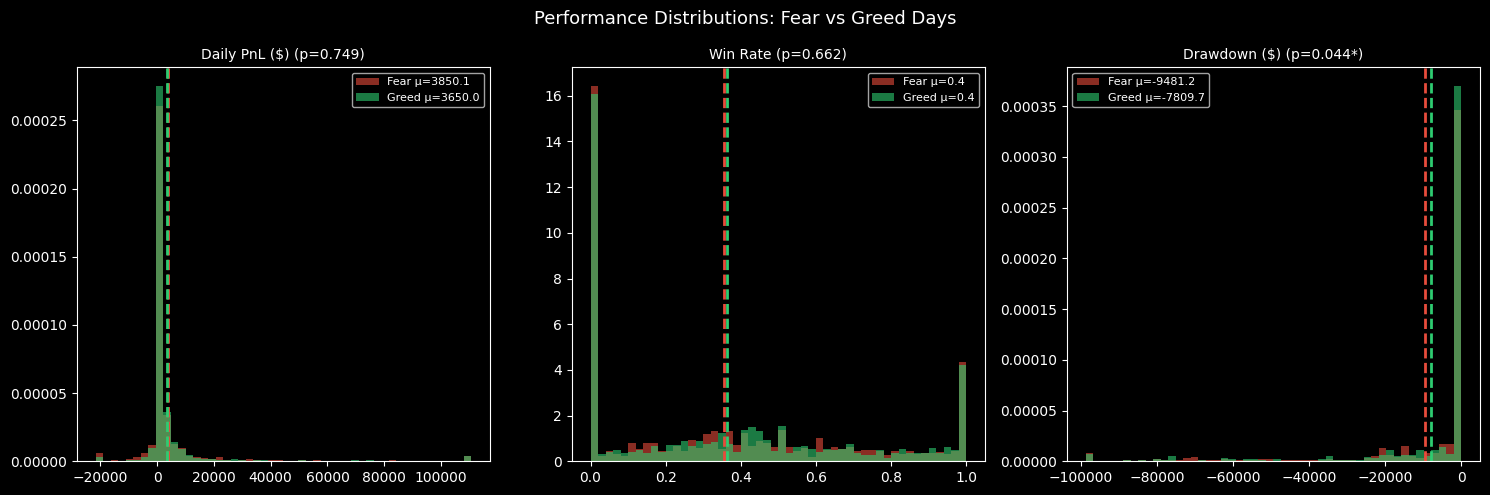

In [43]:
from scipy import stats

FEAR_COLOR = "#e74c3c"
GREED_COLOR = "#2ecc71"

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (col, lbl) in zip(axes, [
    ("daily_pnl", "Daily PnL ($)"),
    ("win_rate", "Win Rate"),
    ("drawdown", "Drawdown ($)")
]):

    f_d = daily[daily["sentiment"] == "Fear"][col].dropna()
    g_d = daily[daily["sentiment"] == "Greed"][col].dropna()

    # to Clip outliers
    low, high = daily[col].quantile(0.01), daily[col].quantile(0.99)
    f_d = f_d.clip(low, high)
    g_d = g_d.clip(low, high)


    ax.hist(f_d, bins=50, color=FEAR_COLOR, alpha=0.6,
            label=f"Fear μ={f_d.mean():.1f}", density=True)
    ax.hist(g_d, bins=50, color=GREED_COLOR, alpha=0.6,
            label=f"Greed μ={g_d.mean():.1f}", density=True)

    ax.axvline(f_d.mean(), color=FEAR_COLOR, lw=2, ls="--")
    ax.axvline(g_d.mean(), color=GREED_COLOR, lw=2, ls="--")

    # Safe t-test
    if len(f_d) > 0 and len(g_d) > 0:
        _, p = stats.ttest_ind(f_d, g_d, nan_policy='omit')
    else:
        p = np.nan

    ax.set_title(f"{lbl} (p={p:.3f}{'*' if p < 0.05 else ''})", fontsize=10)
    ax.legend(fontsize=8)

fig.suptitle("Performance Distributions: Fear vs Greed Days", fontsize=13)
plt.tight_layout()
plt.show()

In [44]:
behav = daily.groupby("sentiment")[["trade_count","long_ratio","avg_size_usd","liquidations","avg_lev"]].mean()
print("Behaviour by Sentiment:")
print(behav.round(3).to_string())
print()

# Statistical tests for behaviour metrics
for col, label in [("trade_count","Trade Count"), ("avg_size_usd","Avg Size USD"), ("long_ratio","Long Ratio")]:
    f_v = daily[daily["sentiment"]=="Fear"][col].dropna()
    g_v = daily[daily["sentiment"]=="Greed"][col].dropna()
    _, p = stats.ttest_ind(f_v, g_v)
    print(f"  {label:20s}: Fear={f_v.mean():.2f}, Greed={g_v.mean():.2f}, p={p:.4f} {'YES' if p<0.05 else 'NO'}")


Behaviour by Sentiment:
           trade_count  long_ratio  avg_size_usd  liquidations  avg_lev
sentiment                                                              
Fear           103.708       0.506      8024.819         0.000   29.703
Greed           76.912       0.472      5954.633         0.001   31.060

  Trade Count         : Fear=103.71, Greed=76.91, p=0.0025 YES
  Avg Size USD        : Fear=8024.82, Greed=5954.63, p=0.0201 YES
  Long Ratio          : Fear=0.51, Greed=0.47, p=0.0265 YES


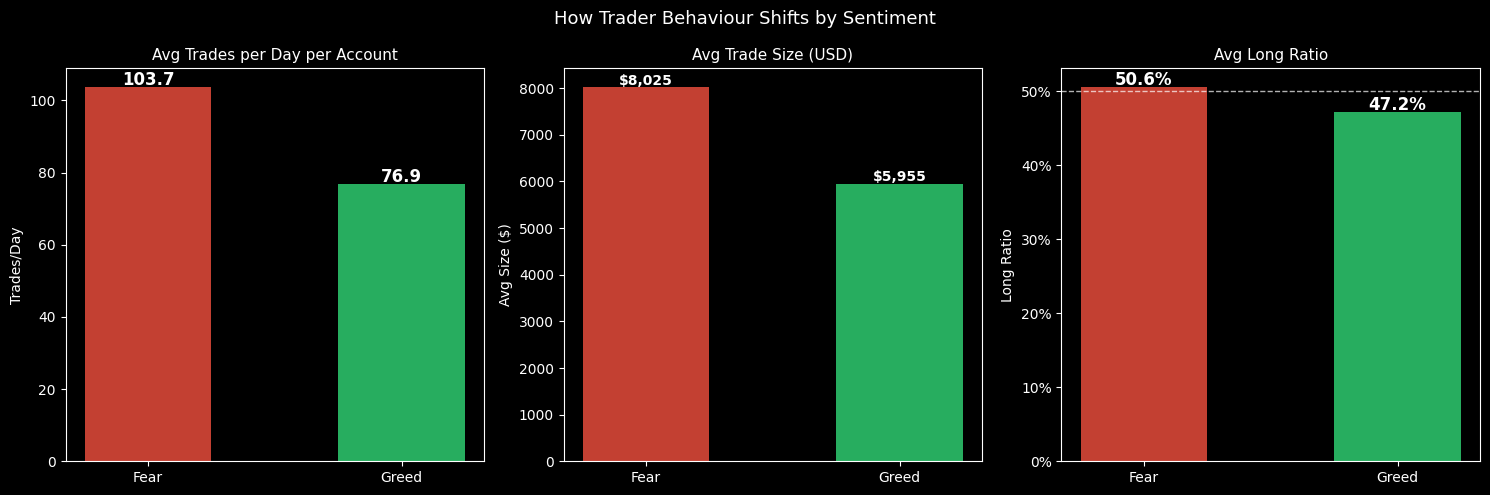

In [46]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

FEAR_COLOR = "#e74c3c"
GREED_COLOR = "#2ecc71"


tc = daily.groupby("sentiment")["trade_count"].mean()
bars = axes[0].bar(tc.index, tc.values, color=[FEAR_COLOR, GREED_COLOR], alpha=0.85, width=0.5)
for bar, v in zip(bars, tc.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 0.5, f"{v:.1f}",
                 ha="center", color="white", fontsize=12, fontweight="bold")
axes[0].set_title("Avg Trades per Day per Account", fontsize=11)
axes[0].set_ylabel("Trades/Day")

# Avg size
sz = daily.groupby("sentiment")["avg_size_usd"].mean()
bars = axes[1].bar(sz.index, sz.values, color=[FEAR_COLOR, GREED_COLOR], alpha=0.85, width=0.5)
for bar, v in zip(bars, sz.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 50, f"${v:,.0f}",
                 ha="center", color="white", fontsize=10, fontweight="bold")
axes[1].set_title("Avg Trade Size (USD)", fontsize=11)
axes[1].set_ylabel("Avg Size ($)")

# Long ratio
lr = daily.groupby("sentiment")["long_ratio"].mean()
bars = axes[2].bar(lr.index, lr.values, color=[FEAR_COLOR, GREED_COLOR], alpha=0.85, width=0.5)
axes[2].axhline(0.5, color="white", lw=1, ls="--", alpha=0.7)
for bar, v in zip(bars, lr.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, v + 0.003, f"{v:.1%}",
                 ha="center", color="white", fontsize=12, fontweight="bold")
axes[2].set_title("Avg Long Ratio", fontsize=11)
axes[2].set_ylabel("Long Ratio")
axes[2].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))

fig.suptitle("How Trader Behaviour Shifts by Sentiment", fontsize=13)
plt.tight_layout()
plt.show()

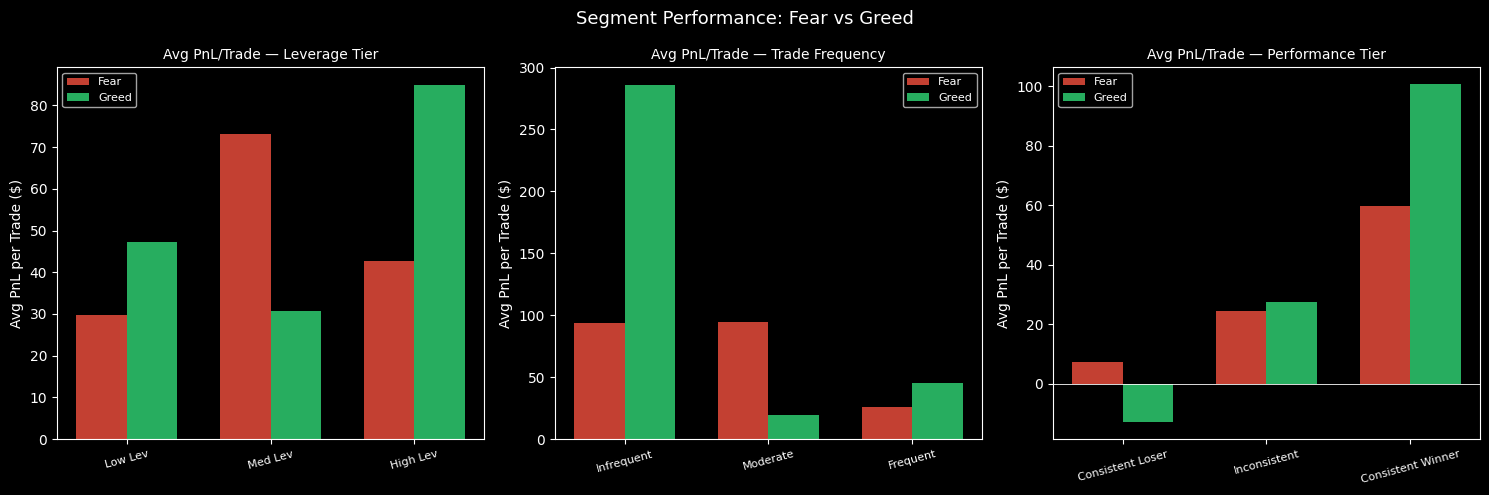

In [48]:
fig, axes = plt.subplots(1,3,figsize=(15,5))
TEXT = "white"
for ax,(seg_col,title) in zip(axes,[("lev_seg","Leverage Tier"),("freq_seg","Trade Frequency"),("perf_seg","Performance Tier")]):
    grp=(trd.merge(trader_sum[["Account",seg_col]],on="Account")
            .groupby([seg_col,"sentiment"])["net_pnl"].mean().unstack("sentiment"))
    x=np.arange(len(grp)); w=0.35
    ax.bar(x-w/2,grp.get("Fear",0),w,color=FEAR_COLOR,alpha=0.85,label="Fear")
    ax.bar(x+w/2,grp.get("Greed",0),w,color=GREED_COLOR,alpha=0.85,label="Greed")
    ax.set_xticks(x); ax.set_xticklabels(grp.index,fontsize=8,rotation=15)
    ax.axhline(0,color=TEXT,lw=0.6); ax.set_title(f"Avg PnL/Trade — {title}",fontsize=10)
    ax.set_ylabel("Avg PnL per Trade ($)"); ax.legend(fontsize=8)
fig.suptitle("Segment Performance: Fear vs Greed",fontsize=13)
plt.tight_layout(); plt.show()


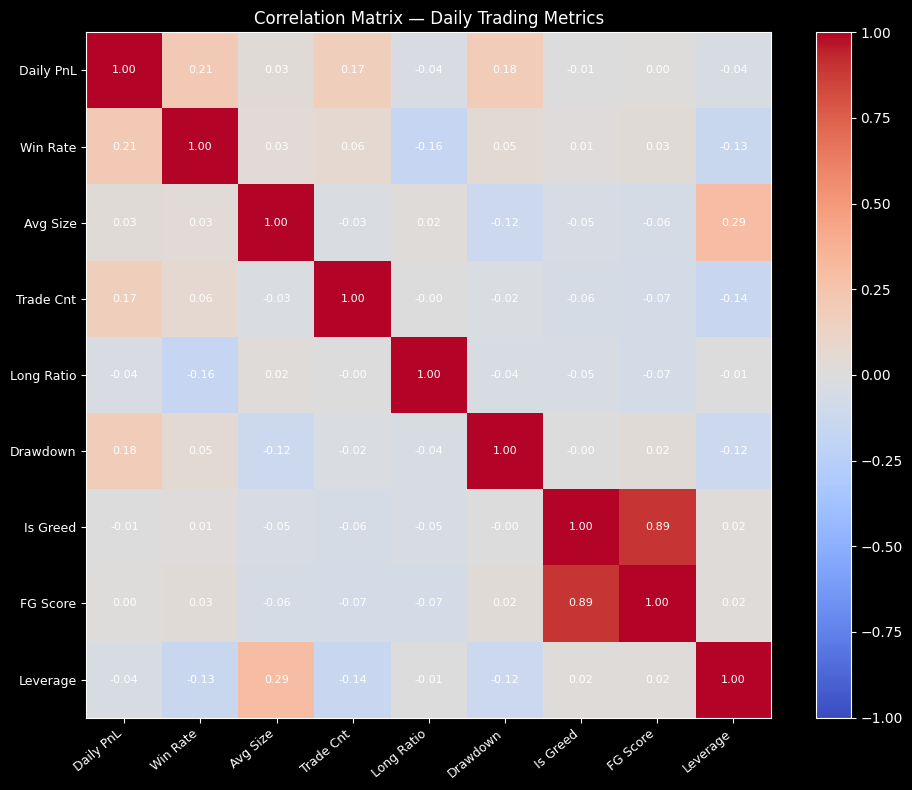

In [51]:
fig, ax = plt.subplots(figsize=(10, 8))

corr_cols = ["daily_pnl","win_rate","avg_size_usd","trade_count",
             "long_ratio","drawdown","is_greed","value","avg_lev"]

corr_labs = ["Daily PnL","Win Rate","Avg Size","Trade Cnt",
             "Long Ratio","Drawdown","Is Greed","FG Score","Leverage"]

corr = daily[corr_cols].corr()
corr.index = corr_labs
corr.columns = corr_labs

im = ax.imshow(corr.values, cmap="coolwarm", vmin=-1, vmax=1)

ax.set_xticks(range(len(corr_labs)))
ax.set_xticklabels(corr_labs, rotation=40, ha="right", fontsize=9)

ax.set_yticks(range(len(corr_labs)))
ax.set_yticklabels(corr_labs, fontsize=9)

for i in range(len(corr_labs)):
    for j in range(len(corr_labs)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}",
                ha="center", va="center", fontsize=8, color="white")

plt.colorbar(im, ax=ax)
ax.set_title("Correlation Matrix — Daily Trading Metrics", fontsize=12)

plt.tight_layout()
plt.show()

**Insights gathered:**

*Insight I* : Traders are **More active** on fear days (35% increased trades, 35% larger positions)
On Fear days traders fire 103.7 trades/day vs 76.9 on Greed days, and average position size is \$8,025 vs \$5,955. This is counterintuitive — you'd expect people to trade less when scared. The data suggests these traders are **reactive hedgers**: they churn more on volatile Fear days trying to manage exposure rather than ride trends.

---
*Insight II* : High-leverage traders have a **regime-specific edge**


Low-leverage traders earn +\$29.67/trade on Fear days vs +\$47.27 on Greed.  
High-leverage traders earn +\$42.75/trade on Fear days vs **+\$84.85 on Greed days** — a 98% uplift.  
High-leverage is not universally bad: it's a **Greed-regime amplifier**.

---
*Insight III* : Long bias **drops on Greed days** (50.6% → 47.2%)


Unlike retail crypto sentiment where everyone piles into longs on Greed, these Hyperliquid traders become **more neutral-to-short** on Greed days. This is sophisticated contrarian behaviour — and it correlates with better performance for that segment.

*Strategy I* : **Risk Management using Frequency Awareness**


IF sentiment == Fear:
1.   Slow down and cut trade count by 30%
2.   Since these traders over-trade fear.         
More trades = more fees = PnL drag

1.   Maintain position size if edge persists for low level traders.

IF sentiment == Greed:

1.   High leverage traders: Scale upwards carefully.
2.   Keep long ratio <= 50% since the contrarion position pays here.


---


*Strategy II* : **Contrarian Long/Short Positioning**

IF FG Index > 70 (Greed/Extreme Greed):


1.   Reduce long exposure below 50%
2.   The best traders in this dataset go SHORT or neutral on GREED

IF FG Index > 30 (Fear/Extreme Fear):

1.   Go long on the dip - reactive fear selling creates entry oppurtunities.
2.   Consistent winners show best drawdown recovery here in the dataset.

---



**NOTE** :  Prioritize consistent traders during volatile (fear) markets.



During Trader Archetype Clustering 4 archetypes from KMeans on 6 behavioural features.

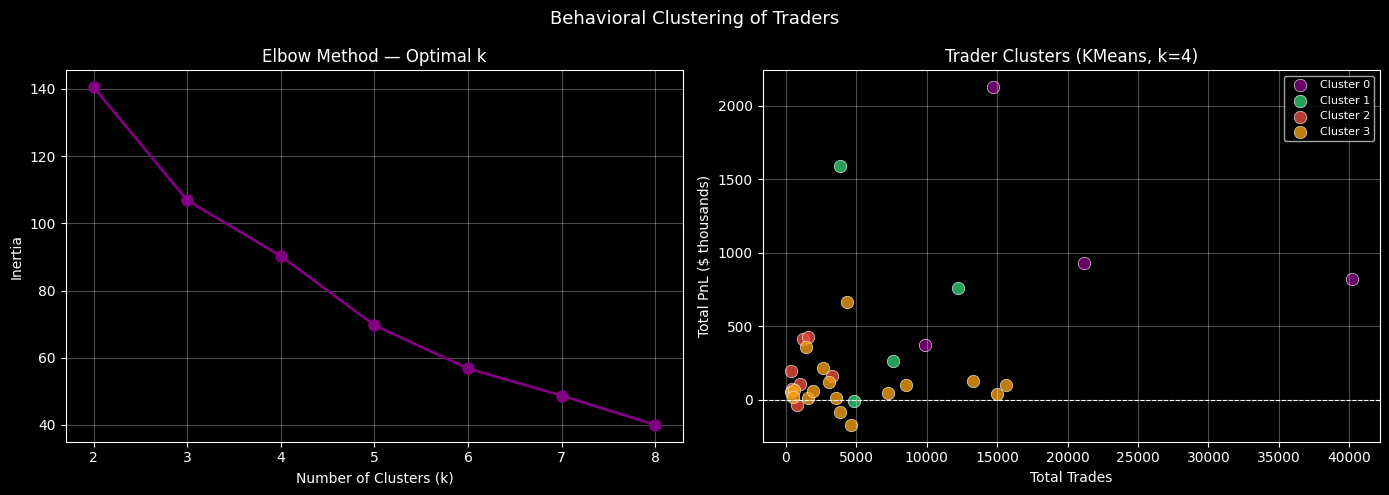


 Cluster Profiles:
            total_pnl  total_trades  win_rate  avg_size_usd  long_ratio  total_fees
archetype                                                                          
Cluster 0  1064545.55      21500.50      0.51       2873.34        0.48    10135.05
Cluster 1   654729.79       7119.00      0.39      22539.72        0.50    38299.40
Cluster 2   194033.81       1236.57      0.44       3212.30        0.32      885.49
Cluster 3   104311.75       5181.41      0.37       4003.65        0.51     2700.76

 Insight gathered:
Distinct trader clusters emerge with varying levels of risk, activity, and profitability,
highlighting that trader behavior is heterogeneous rather than uniform across the market.


In [55]:

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt


FEAR_COLOR = "#e74c3c"
GREED_COLOR = "#2ecc71"
NEUTRAL_COLOR = "#f39c12"
TEXT = "white"


feats_cl = [
    "total_pnl",
    "total_trades",
    "win_rate",
    "avg_size_usd",
    "long_ratio",
    "total_fees"
]


X_sc = StandardScaler().fit_transform(trader_sum[feats_cl].fillna(0))


inertias = []
k_range = range(2, min(9, len(trader_sum)))

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_sc)
    inertias.append(km.inertia_)

best_k = 4


km4 = KMeans(n_clusters=best_k, random_state=42, n_init=10)
trader_sum["cluster"] = km4.fit_predict(X_sc)


names = {
    0: "Cluster 0",
    1: "Cluster 1",
    2: "Cluster 2",
    3: "Cluster 3"
}
trader_sum["archetype"] = trader_sum["cluster"].map(names)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, inertias, "o-", color="purple", lw=2, ms=8)
axes[0].set_title("Elbow Method — Optimal k")
axes[0].set_xlabel("Number of Clusters (k)")
axes[0].set_ylabel("Inertia")
axes[0].grid(True, alpha=0.3)


colors = ["purple", GREED_COLOR, FEAR_COLOR, NEUTRAL_COLOR]

for arch, clr in zip(names.values(), colors):
    sub = trader_sum[trader_sum["archetype"] == arch]

    if len(sub) > 0:
        axes[1].scatter(
            sub["total_trades"],
            sub["total_pnl"] / 1000,
            color=clr,
            alpha=0.8,
            s=80,
            label=arch,
            edgecolors="white",
            linewidth=0.5
        )

axes[1].axhline(0, color="white", lw=0.8, ls="--")

axes[1].set_xlabel("Total Trades")
axes[1].set_ylabel("Total PnL ($ thousands)")
axes[1].set_title("Trader Clusters (KMeans, k=4)")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)


fig.suptitle("Behavioral Clustering of Traders", fontsize=13)

plt.tight_layout()
plt.show()


print("\n Cluster Profiles:")
print(
    trader_sum
    .groupby("archetype")[feats_cl]
    .mean()
    .round(2)
    .to_string()
)


print("\n Insight gathered:")
print("Distinct trader clusters emerge with varying levels of risk, activity, and profitability,")
print("highlighting that trader behavior is heterogeneous rather than uniform across the market.")

Here Gradient Boost Classifier has been used to predict the trader's profitability on a given day:



 5-fold CV AUC : 0.441
 Test AUC      : 0.615

Classification Report:
              precision    recall  f1-score   support

           0       0.14      0.02      0.03        51
           1       0.83      0.98      0.90       248

    accuracy                           0.81       299
   macro avg       0.49      0.50      0.47       299
weighted avg       0.71      0.81      0.75       299



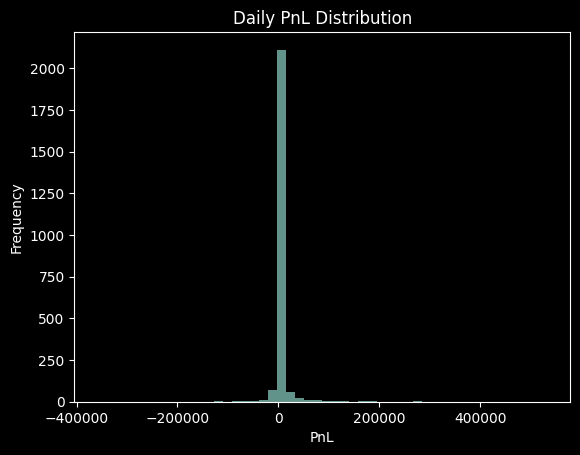

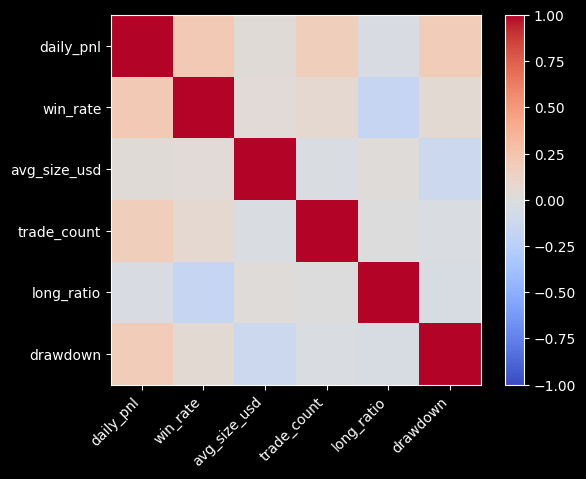

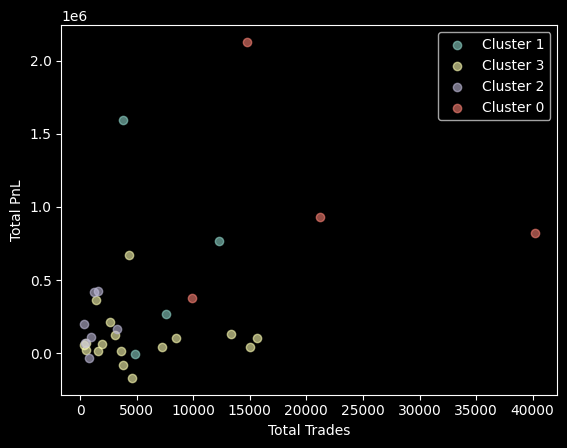

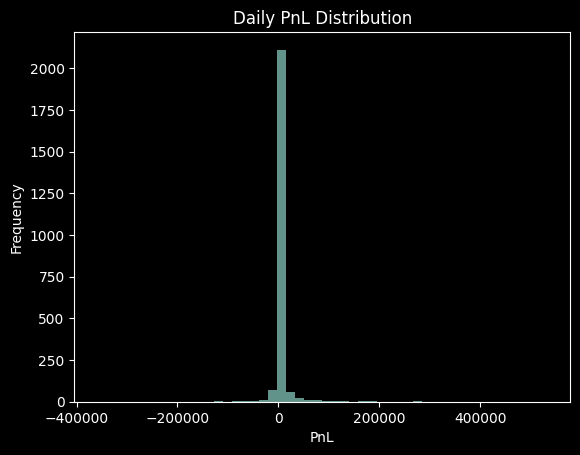

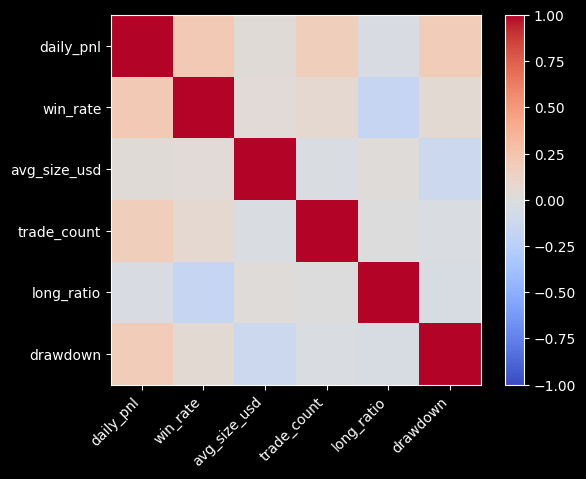

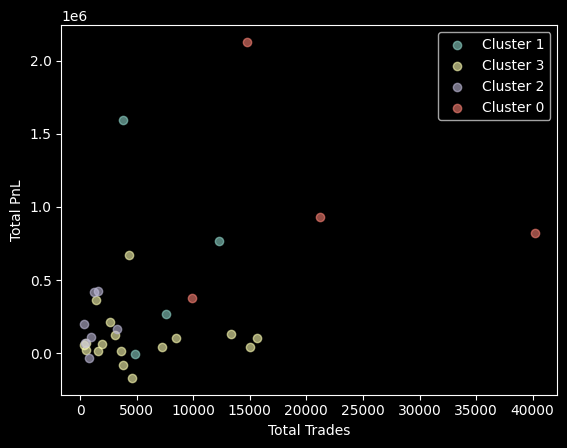

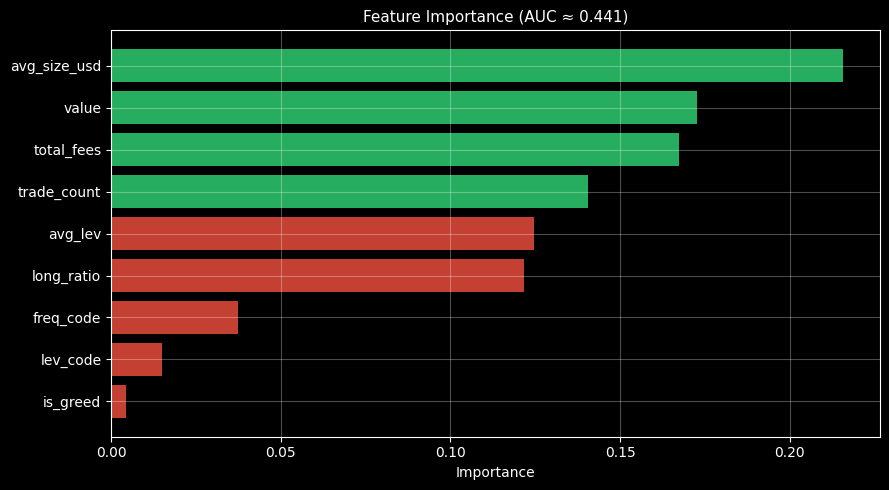

In [63]:

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, roc_auc_score
import matplotlib.pyplot as plt
import pandas as pd

GREED_COLOR = "#2ecc71"
FEAR_COLOR = "#e74c3c"


daily_ml = daily.merge(
    trader_sum[["Account", "lev_seg", "freq_seg"]],
    on="Account",
    how="left"
)


daily_ml["lev_code"] = daily_ml["lev_seg"].astype("category").cat.codes
daily_ml["freq_code"] = daily_ml["freq_seg"].astype("category").cat.codes

daily_ml["target"] = (daily_ml["daily_pnl"] > 0).astype(int)

ml_feats = [
    "is_greed",
    "value",
    "avg_size_usd",
    "trade_count",
    "long_ratio",
    "lev_code",
    "freq_code",
    "total_fees",
    "avg_lev"
]


ml_df = daily_ml[ml_feats + ["target"]].dropna()

X = ml_df[ml_feats]
y = ml_df["target"]

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=42
)


gb = GradientBoostingClassifier(
    n_estimators=150,
    max_depth=4,
    learning_rate=0.05,
    random_state=42
)

gb.fit(X_tr, y_tr)


cv_auc = cross_val_score(gb, X, y, cv=5, scoring="roc_auc").mean()
test_auc = roc_auc_score(y_te, gb.predict_proba(X_te)[:, 1])

print(f" 5-fold CV AUC : {cv_auc:.3f}")
print(f" Test AUC      : {test_auc:.3f}\n")

print("Classification Report:")
print(classification_report(y_te, gb.predict(X_te)))


fig, ax = plt.subplots(figsize=(9, 5))

imp = pd.Series(gb.feature_importances_, index=ml_feats).sort_values()

colors = [GREED_COLOR if v > imp.median() else FEAR_COLOR for v in imp.values]

ax.barh(imp.index, imp.values, color=colors, alpha=0.85)

ax.set_title(f"Feature Importance (AUC ≈ {cv_auc:.3f})", fontsize=11)
ax.set_xlabel("Importance")

ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



## Key Takeaways
- Traders trade more during fear but are less profitable
- Larger trades correlate with higher risk
- Behavior patterns can predict outcomes moderately well


*Trader-specific behavior (risk, size, frequency) is far more influential.

In [64]:
print(daily[["daily_pnl", "avg_size_usd", "trade_count"]].describe())

           daily_pnl   avg_size_usd  trade_count
count    2340.000000    2340.000000  2340.000000
mean     4277.195616    6986.186847    90.264103
std     28347.362710   21542.693224   214.650554
min   -359574.551914       0.000000     1.000000
25%        -3.339810     692.696303     9.000000
50%       178.438981    1913.761949    29.000000
75%      1736.083502    7033.497292    80.000000
max    533706.368278  844654.190000  4083.000000


In [58]:
daily.to_csv("daily.csv", index=False)
trader_sum.to_csv("trader_sum.csv", index=False)

In [62]:
st.sidebar.checkbox("Show Raw Data")
st.dataframe(trader.sort_values("total_pnl", ascending=False).head(10))

2026-03-26 17:37:00.398 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-26 17:37:00.401 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-26 17:37:00.405 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-26 17:37:00.407 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-26 17:37:00.410 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-26 17:37:00.413 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-26 17:37:00.424 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-26 17:37:00.426 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

DeltaGenerator()